#**Bank Marketing**

#Google Drive


In [172]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Import Libraries

In [173]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

#Load Dataset

In [174]:
DATA_PATH = "/content/drive/MyDrive/NN Assignment/Bank/bank-data/bank-full.csv"
SEP = ";"
df = pd.read_csv(DATA_PATH, sep=SEP)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#Dataset Overview

In [175]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns.tolist())
df.info()

Rows: 45211
Columns: 17
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  obj

#Statistical Summary

In [176]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


#Missing & Unknown Values

In [177]:
print("Actual missing values:")
display(df.isnull().sum().sort_values(ascending=False))
print("\n'unknown' values:")
display(pd.Series({c:(df[c]=="unknown").sum() for c in df.select_dtypes("object").columns}).sort_values(ascending=False).to_frame("Count"))

Actual missing values:


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0



'unknown' values:


,Count
poutcome,36959
contact,13020
education,1857
job,288
marital,0
default,0
loan,0
housing,0
month,0
y,0


#Duplicate Values

In [178]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

Duplicate rows: 0


#EDA

##Target Distribution

y
no     39922
yes     5289
Name: count, dtype: int64


,Percentage
y,
no,88.3
yes,11.7


/tmp/ipykernel_5176/230268354.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="y", palette=["#264653", "#014D4E"],


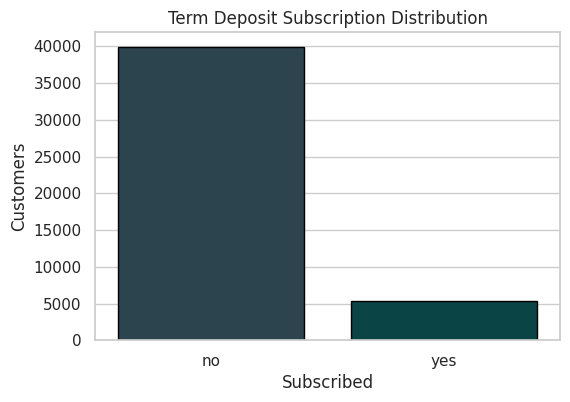

In [179]:
print(df["y"].value_counts())
display((df["y"].value_counts(normalize=True)*100).round(2).to_frame("Percentage"))
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="y", palette=["#264653", "#014D4E"],
        edgecolor="black")
plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Customers")
plt.show()

##Numerical Feature Distributon

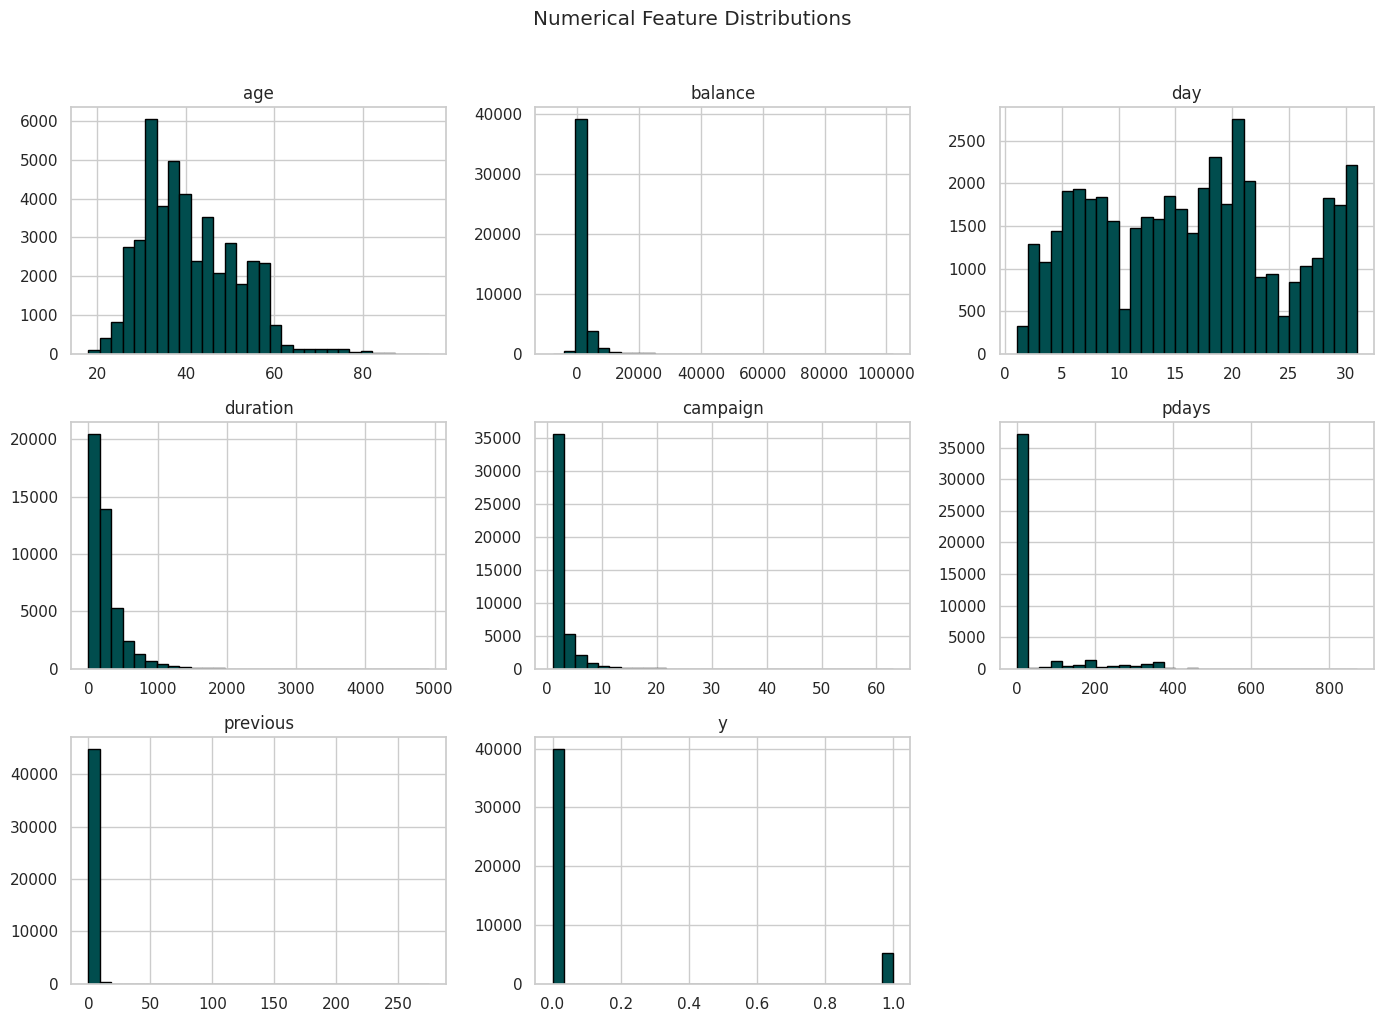

In [201]:
numerical_columns_all = df.select_dtypes(exclude="object").columns.tolist()

df[numerical_columns_all].hist(
    figsize=(14, 10),
    bins=30,
    color="#014D4E",
    edgecolor="black"
)

plt.suptitle(
    "Numerical Feature Distributions",
    y=1.02
)

plt.tight_layout()
plt.show()

##Categorical Feature Distribution

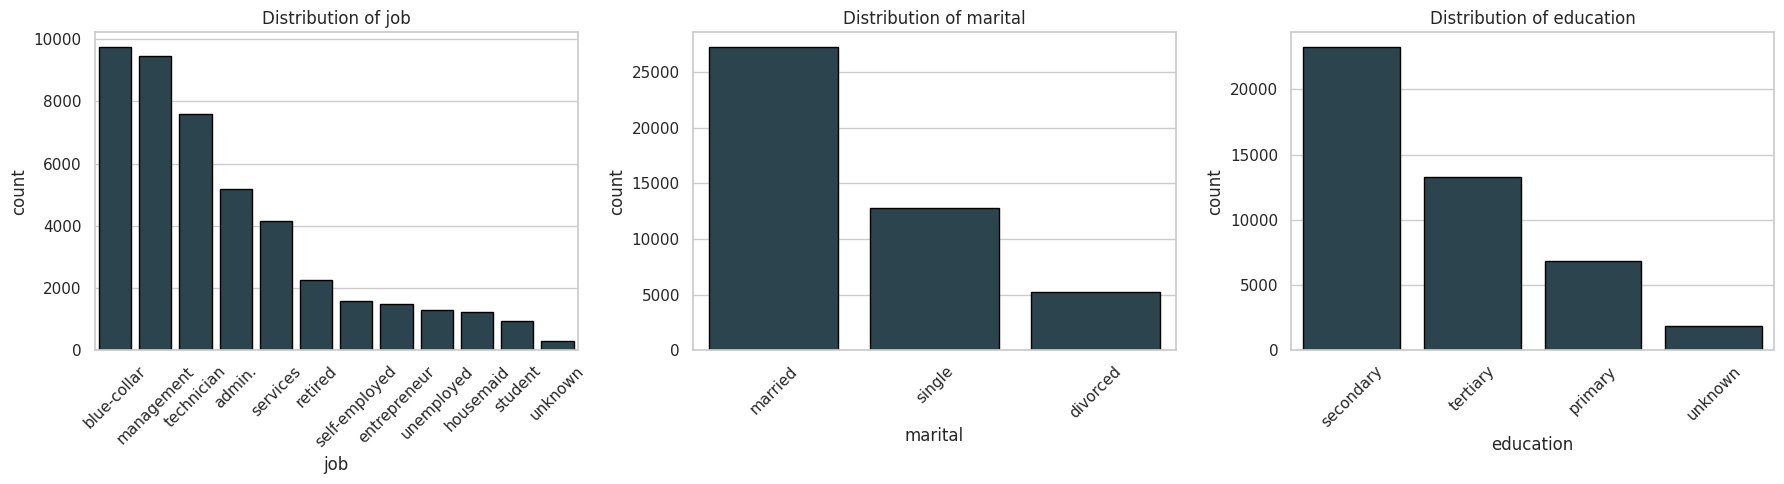

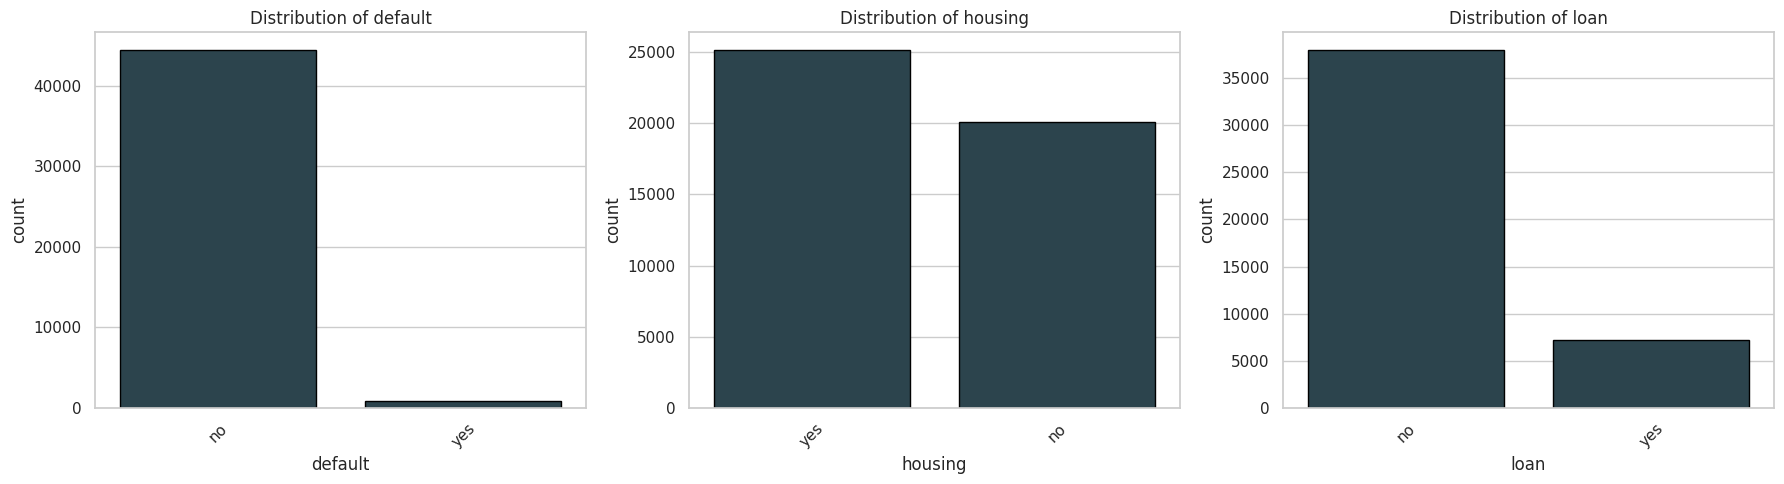

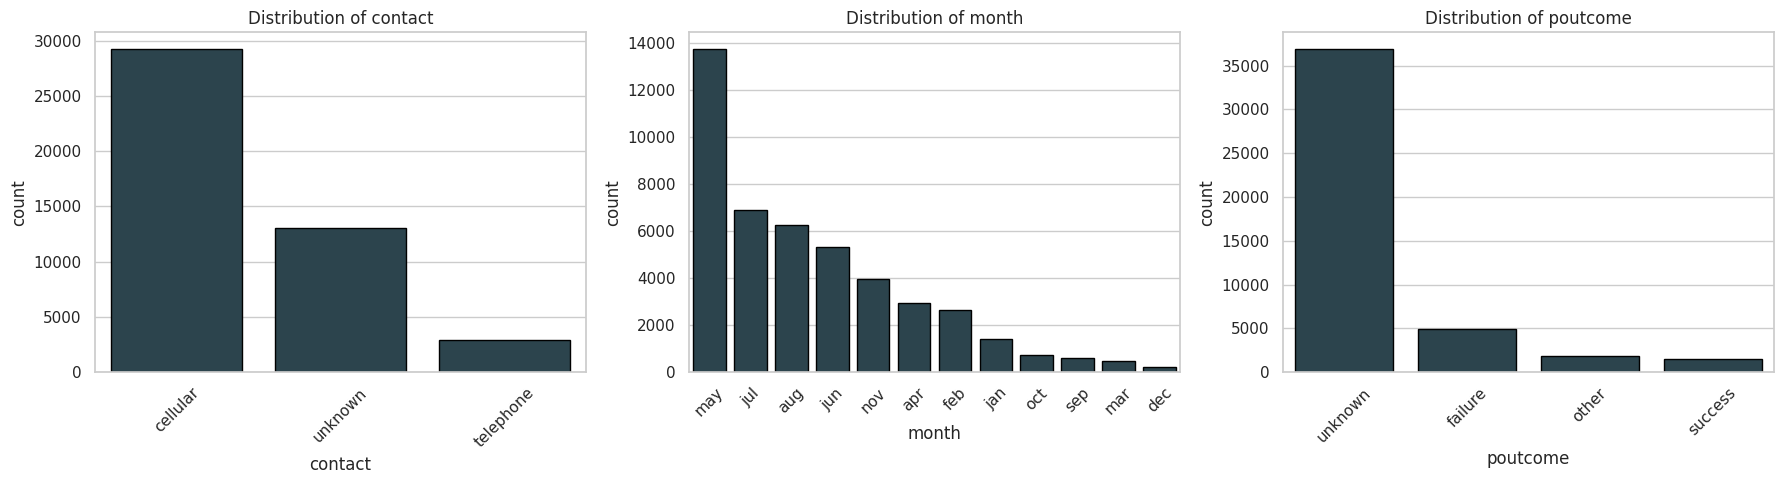

In [181]:
# Plot 3 categorical features side by side
for i in range(0, len(categorical_columns_all), 3):

    cols = categorical_columns_all[i:i+3]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # If fewer than 3 columns remain
    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, cols):

        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            x=col,
            order=order,
            color="#264653",
            edgecolor="black",
            ax=ax
        )

        ax.set_title(f"Distribution of {col}")
        ax.tick_params(axis="x", rotation=45)

    # Hide unused subplot(s)
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


##Subscription Rate by Categorical features

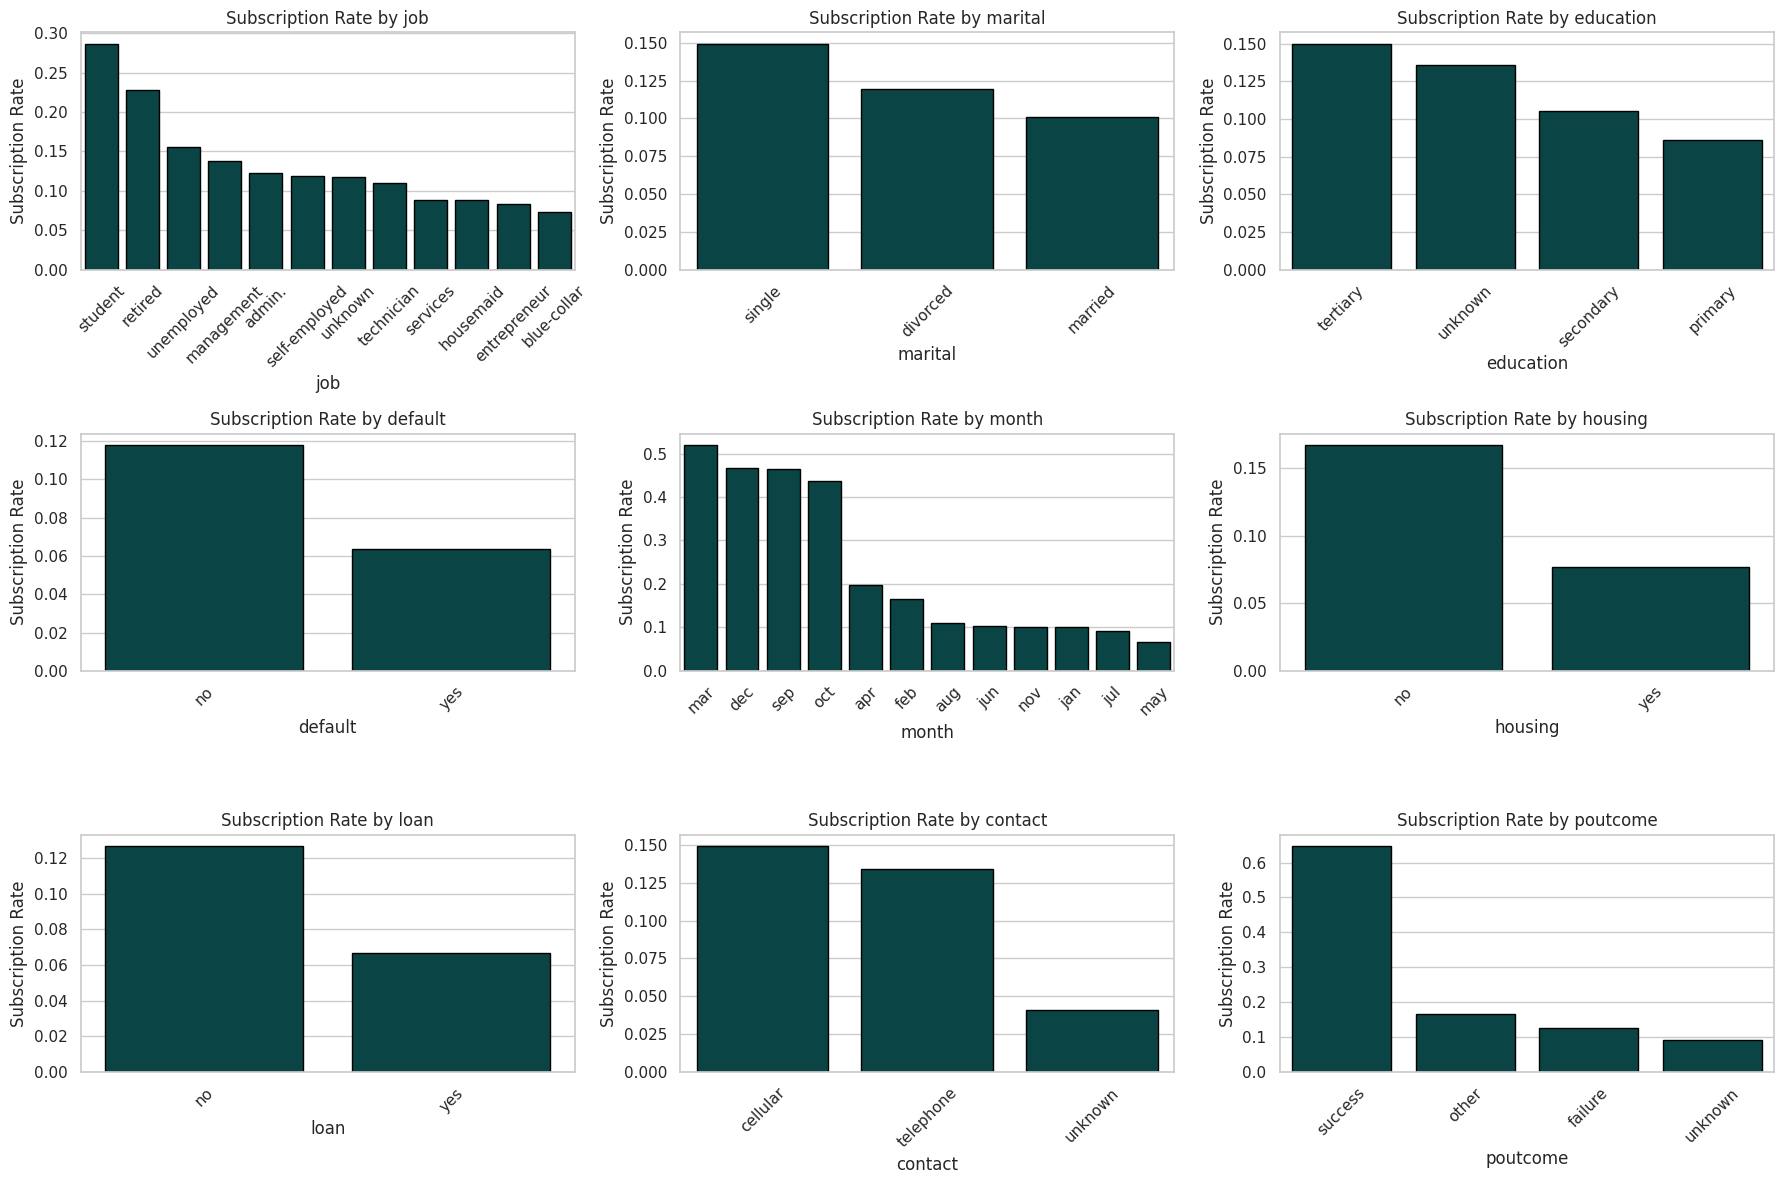

In [182]:
important_categorical = [
    "job", "marital", "education",
    "default", "month", "housing",
    "loan", "contact", "poutcome"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, important_categorical):

    rate = (
        df.groupby(col)["y"]
        .apply(lambda s: (s == "yes").mean())
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=rate.index,
        y=rate.values,
        color="#014D4E",
        edgecolor="black",
        ax=ax
    )

    ax.set_title(f"Subscription Rate by {col}")
    ax.set_ylabel("Subscription Rate")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

##Correlational Heatmap

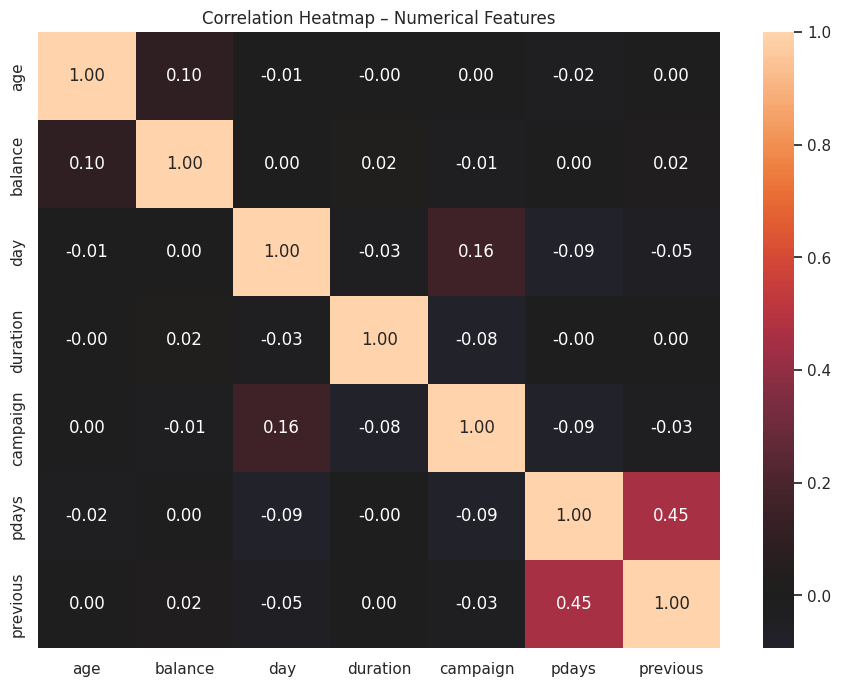

In [183]:
plt.figure(figsize=(11,8))
sns.heatmap(df.select_dtypes(exclude="object").corr(),annot=True,fmt=".2f",center=0)
plt.title("Correlation Heatmap – Numerical Features")
plt.show()

##Data Quality Check

In [184]:
print("pdays = -1:",(df["pdays"]==-1).sum())
print("Percentage:",round((df["pdays"]==-1).mean()*100,2),"%")

pdays = -1: 36954
Percentage: 81.74 %


#Data Preparation

##Encode Target Variable

In [185]:
df["y"]=df["y"].map({"no":0,"yes":1}).astype(int)
print(df["y"].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


##Seperate Features and Target

In [186]:
X=df.drop("y",axis=1)
y=df["y"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 16)
y shape: (45211,)


##Feature Types

In [187]:
categorical_cols=X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols=X.select_dtypes(exclude=["object"]).columns.tolist()
print("Categorical:",categorical_cols)
print("Numerical:",numerical_cols)

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


##Test-train Split

In [188]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nTarget rates:")
print("Train:", round(y_train.mean(), 4))
print("Validation:", round(y_val.mean(), 4))
print("Test:", round(y_test.mean(), 4))

Training: (28934, 16) (28934,)
Validation: (7234, 16) (7234,)
Test: (9043, 16) (9043,)

Target rates:
Train: 0.117
Validation: 0.1169
Test: 0.117


##Preprocessing Pipeline

In [189]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

numeric_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])
categorical_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])
preprocessor=ColumnTransformer([
    ("num",numeric_pipeline,numerical_cols),
    ("cat",categorical_pipeline,categorical_cols)
])

Processed training shape: (28934, 51)
Processed validation shape: (7234, 51)
Processed testing shape: (9043, 51)


#Logistic Regression

##Train the Model

In [190]:
model=Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(max_iter=2000,class_weight="balanced",random_state=RANDOM_STATE))
])
model.fit(X_train,y_train)
print("Model trained successfully.")

Model trained successfully.


#Model Evalution

##Prediction And Probabilities

In [191]:
y_pred=model.predict(X_test)
y_probability=model.predict_proba(X_test)[:,1]


##Performance Metrics

In [192]:
metrics=pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1-Score","ROC-AUC"],
    "Score":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred,zero_division=0),
        recall_score(y_test,y_pred,zero_division=0),
        f1_score(y_test,y_pred,zero_division=0),
        roc_auc_score(y_test,y_probability)
    ]
})
display(metrics.round(4))

,Metric,Score
0,Accuracy,0.8445
1,Precision,0.4162
2,Recall,0.8166
3,F1-Score,0.5514
4,ROC-AUC,0.9081


##Classification Report

In [193]:
print(classification_report(y_test,y_pred,target_names=["No Subscription","Subscription"],zero_division=0))

                 precision    recall  f1-score   support

No Subscription       0.97      0.85      0.91      7985
   Subscription       0.42      0.82      0.55      1058

       accuracy                           0.84      9043
      macro avg       0.69      0.83      0.73      9043
   weighted avg       0.91      0.84      0.86      9043



##Confusion Matrix

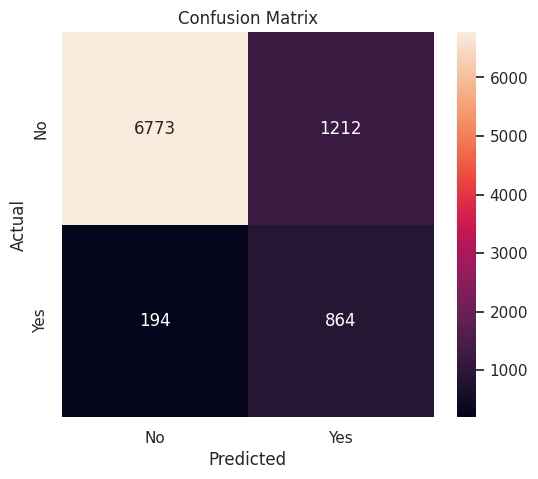

In [199]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=["No","Yes"],yticklabels=["No","Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

##ROC Curve

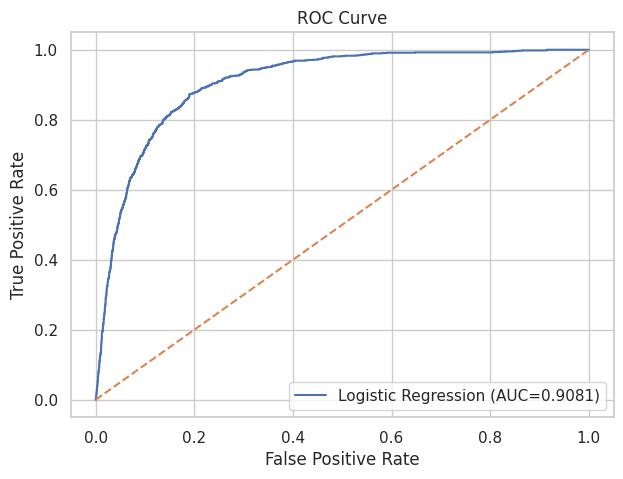

ROC-AUC: 0.9081


In [195]:
roc_auc=roc_auc_score(y_test,y_probability)
fpr,tpr,_=roc_curve(y_test,y_probability)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f"Logistic Regression (AUC={roc_auc:.4f})")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print(f"ROC-AUC: {roc_auc:.4f}")

#Model Interpretation

##Feature Coefficients

In [196]:
classifier=model.named_steps["classifier"]
fitted_preprocessor=model.named_steps["preprocessor"]
feature_names=fitted_preprocessor.get_feature_names_out()
coef_df=pd.DataFrame({"Feature":feature_names,"Coefficient":classifier.coef_[0]})
coef_df["Absolute_Coefficient"]=coef_df["Coefficient"].abs()
display(coef_df.sort_values("Absolute_Coefficient",ascending=False).head(15))

,Feature,Coefficient,Absolute_Coefficient
49,cat__poutcome_success,1.798549,1.798549
42,cat__month_mar,1.731391,1.731391
3,num__duration,1.533935,1.533935
39,cat__month_jan,-1.410906,1.410906
45,cat__month_oct,1.194704,1.194704
40,cat__month_jul,-1.065486,1.065486
34,cat__contact_unknown,-1.051738,1.051738
46,cat__month_sep,0.973201,0.973201
44,cat__month_nov,-0.972700,0.972700
37,cat__month_dec,0.832707,0.832707


#New Customer Prediction

##New Customer

In [197]:
new_customer=pd.DataFrame({
    "age":[35],"job":["management"],"marital":["married"],"education":["tertiary"],
    "default":["no"],"balance":[1500],"housing":["yes"],"loan":["no"],
    "contact":["cellular"],"day":[10],"month":["may"],"duration":[300],
    "campaign":[1],"pdays":[-1],"previous":[0],"poutcome":["unknown"]
})
display(new_customer)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,35,management,married,tertiary,no,1500,yes,no,cellular,10,may,300,1,-1,0,unknown


##Predict Subscription

In [198]:
new_probability=model.predict_proba(new_customer)[0,1]
new_prediction=model.predict(new_customer)[0]
print("Predicted class:","Yes" if new_prediction==1 else "No")
print(f"Probability of subscription: {new_probability:.4f}")

Predicted class: No
Probability of subscription: 0.3230
